In [21]:
# 1. IMPORTACIONES Y CONFIGURACIÓN VISUAL
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore') # Ocultar avisos de librerías para mantener el cuaderno limpio

# Configuración de estilo profesional para el TFG (Memoria)
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 12, 
    'figure.figsize': (10, 6),
    'axes.titlepad': 15,
    'axes.titleweight': 'bold'
})
colores_target = ['#2ECC71', '#E74C3C'] # Verde (A tiempo/Seguro) y Rojo (Retraso/Riesgo)

# Carga del Dataset Limpio
df = pd.read_csv('../data/processed/dataset_entrenamiento_tawos.csv')
print(f"✅ Dataset cargado correctamente: {df.shape[0]} tareas listas para análisis exploratorio.")
display(df.head(3))

✅ Dataset cargado correctamente: 142151 tareas listas para análisis exploratorio.


,Issue_Key,Summary,Issue_Type,Project_ID,Project_Name,Sprint_ID,Sprint_State,Story_Point,Total_Effort_Minutes,In_Progress_Minutes,Resolution_Time_Minutes,Title_Changed_After_Estimation,Description_Changed_After_Estimation,Story_Point_Changed_After_Estimation,Blocker_Count,Target_Retraso,Target_Riesgo
0,XD-3748,"""Unable to register the JMX bean MessageHistor...",Bug,1,Spring XD,-1,UNASSIGNED,1.0,428822.0,87.0,436558.0,0,0,0,0,0,1
1,XD-3747,"""Rabbit Bus: Expose ChannelCacheSize on Cachin...",Enhancement,1,Spring XD,-1,UNASSIGNED,1.0,336752.0,2.0,437537.0,1,0,0,0,0,1
2,XD-3744,"""Suppress DeliveryMode Header in RabbitMQ Source""",Enhancement,1,Spring XD,1,CLOSED,1.0,172.0,13.0,194.0,0,0,0,0,0,0


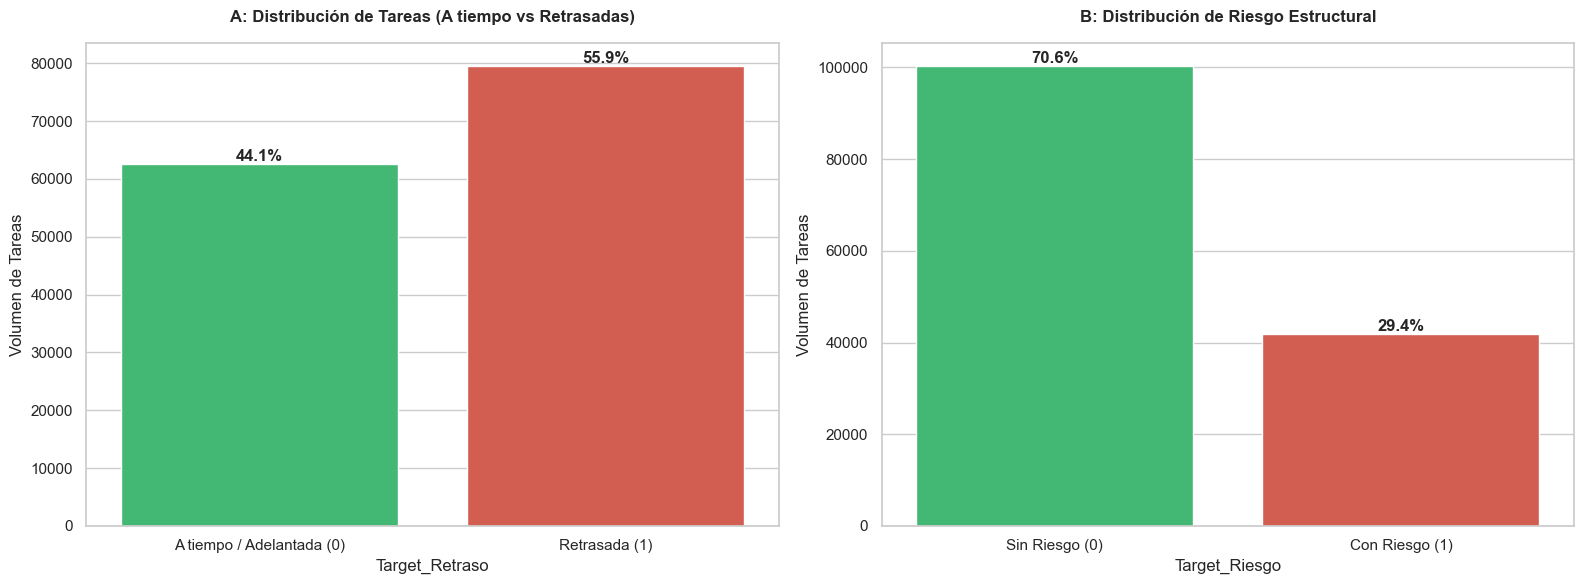

In [22]:
# 2. ANÁLISIS DE DISTRIBUCIÓN DE CLASES (EL PROBLEMA EMPÍRICO)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico A: Retrasos
ax1 = sns.countplot(data=df, x='Target_Retraso', palette=colores_target, ax=axes[0])
axes[0].set_title('A: Distribución de Tareas (A tiempo vs Retrasadas)')
axes[0].set_xticklabels(['A tiempo / Adelantada (0)', 'Retrasada (1)'])
axes[0].set_ylabel('Volumen de Tareas')

# Etiquetas Gráfico A
total1 = len(df)
for p in ax1.patches:
    porcentaje = f'{100 * p.get_height() / total1:.1f}%'
    ax1.annotate(porcentaje, (p.get_x() + p.get_width() / 2, p.get_height()), #coloca el texto de la barra
                 ha='center', va='bottom', fontweight='bold', fontsize=12)

# Gráfico B: Riesgos
ax2 = sns.countplot(data=df, x='Target_Riesgo', palette=colores_target, ax=axes[1])
axes[1].set_title('B: Distribución de Riesgo Estructural')
axes[1].set_xticklabels(['Sin Riesgo (0)', 'Con Riesgo (1)'])
axes[1].set_ylabel('Volumen de Tareas')

# Etiquetas Gráfico B
for p in ax2.patches:
    porcentaje = f'{100 * p.get_height() / total1:.1f}%'
    ax2.annotate(porcentaje, (p.get_x() + p.get_width() / 2, p.get_height()), 
                 ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.tight_layout()
# Descomenta la siguiente línea si quieres que la imagen se guarde sola en tu disco duro
# plt.savefig('../data/figures/distribucion_targets.png', dpi=300, bbox_inches='tight')
plt.show()

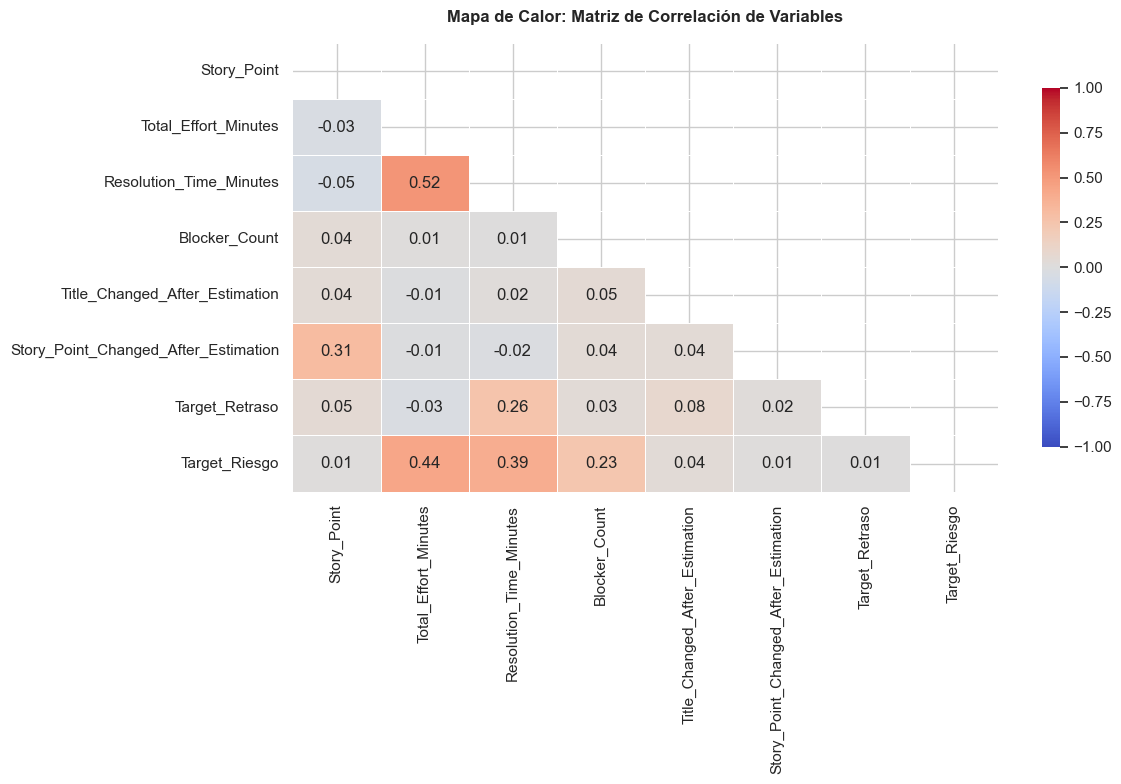

In [23]:
# 3. MATRIZ DE CORRELACIÓN (¿Qué influye en los retrasos y riesgos?)
cols_correlacion = [
    'Story_Point', 'Total_Effort_Minutes', 'Resolution_Time_Minutes', 
    'Blocker_Count', 'Title_Changed_After_Estimation', 
    'Story_Point_Changed_After_Estimation', 
    'Target_Retraso', 'Target_Riesgo'
]

plt.figure(figsize=(12, 8))
matriz_corr = df[cols_correlacion].corr() #coeficiente correlación pearson

# Crear máscara para ocultar el triángulo superior (hace que el gráfico sea más elegante y limpio)
mask = np.triu(np.ones_like(matriz_corr, dtype=bool))

sns.heatmap(matriz_corr, annot=True, mask=mask, cmap='coolwarm', fmt=".2f",  
            linewidths=0.5, vmin=-1, vmax=1, cbar_kws={"shrink": .8}) #creación mapa de calor

plt.title('Mapa de Calor: Matriz de Correlación de Variables')
plt.tight_layout()
# plt.savefig('../data/figures/matriz_correlacion.png', dpi=300, bbox_inches='tight')
plt.show()

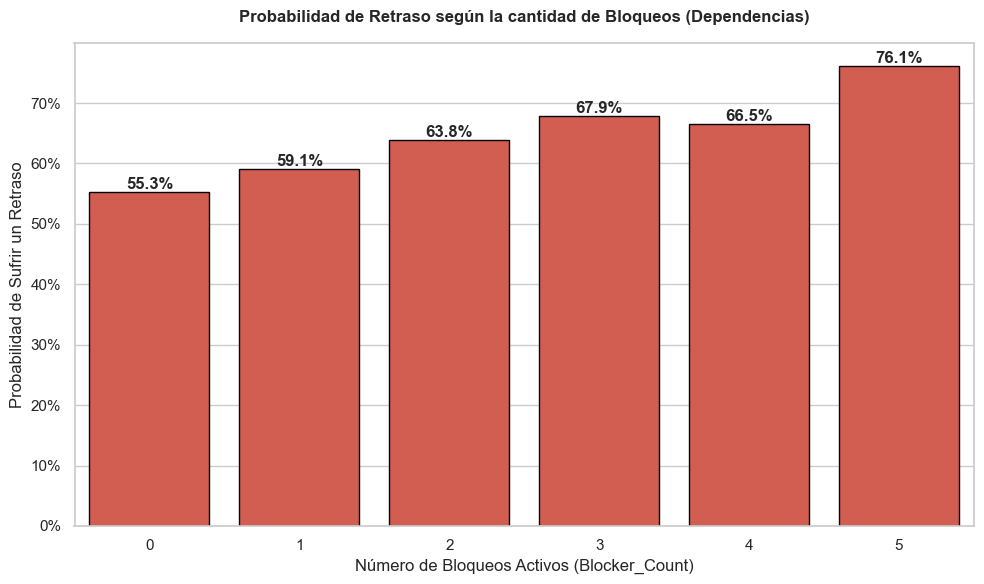

In [24]:
# 4. IMPACTO DE LOS BLOQUEOS EN EL RETRASO
plt.figure(figsize=(10, 6))

# Filtramos para no ver valores extremos (>5 bloqueos) y hacer el gráfico representativo
df_bloqueos = df[df['Blocker_Count'] <= 5]

ax = sns.barplot(data=df_bloqueos, x='Blocker_Count', y='Target_Retraso', 
                 color='#E74C3C', ci=None, edgecolor='black')

plt.title('Probabilidad de Retraso según la cantidad de Bloqueos (Dependencias)')
plt.xlabel('Número de Bloqueos Activos (Blocker_Count)')
plt.ylabel('Probabilidad de Sufrir un Retraso')

# Formatear eje Y como porcentaje
from matplotlib.ticker import PercentFormatter
ax.yaxis.set_major_formatter(PercentFormatter(1))

# Añadir etiquetas de porcentaje encima de las barras
for p in ax.patches:
    ax.annotate(f"{p.get_height()*100:.1f}%", 
                (p.get_x() + p.get_width() / 2, p.get_height()), 
                ha='center', va='bottom', fontweight='bold') 
plt.tight_layout()
# plt.savefig('../data/figures/impacto_bloqueos.png', dpi=300, bbox_inches='tight')
plt.show()